## PPOL 5205 Data Science Final Project
### Katharyn Loweth
### Script 2: Sentiment and perspective analysis of movie taglines (prepped through the Script 1 data cleaning code)

In [9]:
#loading in libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer 
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer

from nrclex import NRCLex

In [10]:
pwd()

'/Users/katharynloweth/Desktop/Data_Science_III/Final_Project'

In [11]:
#loading in cleaned dataset and NRC emotion lexicon
movies = pd.read_csv("1974_2024_englishlanguagefilms.csv")
nrc = pd.read_csv("nrc.csv")


In [59]:
count_plotNA = movies['imdb_plot'].value_counts().get('NA', 0)
count_plotNA

0

### Initial Exploration of Sentiment in Taglines

In [12]:
tags = movies[["id","title", "tagline"]].reset_index(drop = True)
tags.shape

(5275, 3)

In [13]:
stop_words_2 = ['what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 
                'been', 'being', 'have', 'has', 'had', 'having', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 
                'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'between', 'into', 
                'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 
                'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 
                'other', 'some', 'such', 'only', 'so', 's', 't', 'can', 'just', 'don', 'should', "should've", 'd', 'll', 
                'm', 'o', 're', 've', 'y', 'll', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 
                'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', 
                "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 
                'won', 'wouldn', "wouldn't"]

In [14]:
#tokenizing and lemmatizing words; removing stopwords
tags["tokens"] = tags["tagline"].apply(word_tokenize)
tags["tokens"] = tags["tokens"].apply(lambda x: [word.lower() for word in x if word.isalpha()])
tags["tokens"] = tags["tokens"].apply(lambda x: [word for word in x if word not in stop_words_2])


wnl = WordNetLemmatizer()
tags["tokens_lem"] = tags["tokens"].apply(lambda x: [wnl.lemmatize(word) for word in x if word not in stop_words_2])

tags['tokens_join'] = tags['tokens_lem'].apply(' '.join)


In [15]:
tags.tokens_lem.head()

0                       [your, mind, scene, crime]
1    [mankind, born, earth, it, never, meant, die]
2                  [welcome, world, without, rule]
3                          [enter, world, pandora]
4                             [assembly, required]
Name: tokens_lem, dtype: object

In [16]:
tags.tokens_join.head()

0                    your mind scene crime
1    mankind born earth it never meant die
2               welcome world without rule
3                      enter world pandora
4                        assembly required
Name: tokens_join, dtype: object

In [17]:
#looping through count vectorizer with a varying minimum document frequency requirement
#fitting to taglines in the sample and pulling the number of features (shape[1]) from the vectorized matrix
#saving that number in a list
feat = [CountVectorizer(min_df = i).fit_transform(tags.tokens_join).shape[1] for i in range(1,26)]
print(feat)


[3975, 1918, 1336, 1037, 854, 727, 644, 576, 522, 471, 432, 400, 379, 359, 335, 310, 292, 272, 258, 242, 234, 223, 213, 198, 193]


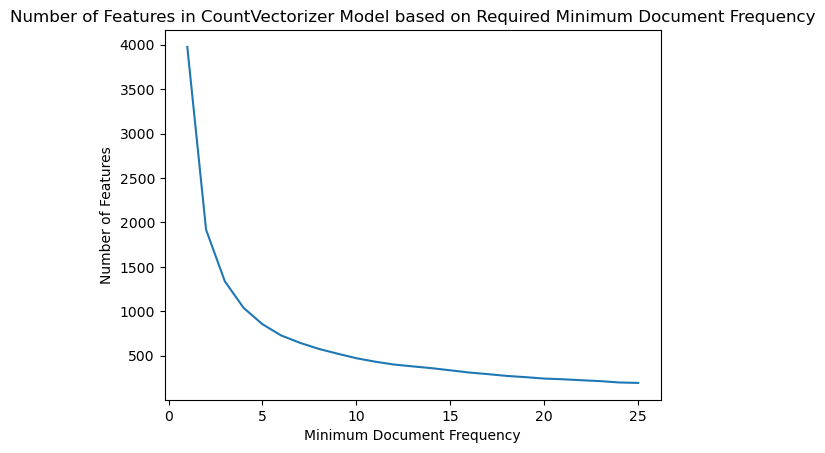

In [18]:
plt.plot(range(1,26), feat)
plt.xlabel('Minimum Document Frequency')
plt.ylabel('Number of Features')
plt.title('Number of Features in CountVectorizer Model based on Required Minimum Document Frequency')
plt.show() 

In [19]:
vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform(tags.tokens_join)
# Convert the matrix to an array and display it
feature_matrix = dtm.todense()

feature_names = vectorizer.get_feature_names_out()

df = pd.DataFrame(feature_matrix, columns=feature_names)
df.head()

,aaron,abby,abduction,able,aboard,abounds,abracatastic,absolute,absolutely,absorbent,...,youth,yule,zebra,zero,zest,zeta,zhivago,zombie,zone,zoo
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
lemtagdf = pd.DataFrame(dtm.toarray(), 
                     columns=vectorizer.get_feature_names_out(), 
                     index=tags.id)

index = lemtagdf.sum().sort_values(ascending=False).index
lemtagdf[index].head()

,you,it,he,one,they,your,love,no,all,life,...,huh,humming,hun,hungry,hurricane,hussle,hustled,hyde,hypothermia,knife
id,,,,,,,,,,,,,,,,,,,,,
27205,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
157336,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
155,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24428,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
#looking at most common words in taglines

tokens_sorted = lemtagdf.sum().sort_values(ascending=False)

sorted_df = tokens_sorted.reset_index()

sorted_df.columns = ['word', 'count']

sorted_df

,word,count
0,you,850
1,it,661
2,he,438
3,one,427
4,they,366
...,...,...
3970,hussle,1
3971,hustled,1
3972,hyde,1
3973,hypothermia,1


In [22]:
#total number of tokens in taglines after prep
tag_words = sorted_df.word.tolist()
tag_words[0:5]

tag_words_num = len(tag_words)
print(tag_words_num)

3975


In [23]:
#looking at NRC lexicon
nrc.head()

,word,sentiment
0,abacus,trust
1,abandon,fear
2,abandon,negative
3,abandon,sadness
4,abandoned,anger


In [24]:
len(nrc.word.unique())

6453

In [25]:
#merging token and NRC datasets
token_nrc = pd.merge(sorted_df, nrc, on='word', how='inner')
token_nrc

,word,count,sentiment
0,love,285,joy
1,love,285,positive
2,time,179,anticipation
3,adventure,105,anticipation
4,adventure,105,positive
...,...,...,...
2996,horrible,1,negative
2997,hungry,1,anticipation
2998,hungry,1,negative
2999,hurricane,1,fear


In [26]:
# proportion of tagline words in NRC lexicon
len(set(token_nrc.word))/len(sorted_df)

0.3011320754716981

In [27]:
#set(token_nrc.word) #looking at sentiment words found in the taglines

In [28]:
# prevalence of each sentiment
token_nrc.value_counts('sentiment')

sentiment
negative        530
positive        511
fear            349
trust           292
anger           270
anticipation    257
joy             226
sadness         218
disgust         178
surprise        170
Name: count, dtype: int64

## Creating and Appending Sentiment and Perspective Dictionary to Movie dataset

Using the python package NRCLex instead of csv file for this part. More information on package and objects is included on PyPi project description (Bailey, 2019) and geeks for geeks example (2021). 

In [29]:
# from https://www.geeksforgeeks.org/emotion-classification-using-nrc-lexicon-in-python/
#testing based on the geeksforgeeks code example
text = ['hate', 'lovely', 'person', 'worst']

for i in range(len(text)):
    # creating objects
    emotion = NRCLex(text[i])
    exclude_emotions = {'positive', 'negative'}
    print('\n\n', text[i], ': ', emotion.top_emotions)
    print({emotion: score for emotion, score in emotion.raw_emotion_scores.items() if emotion not in exclude_emotions})
    print(emotion.affect_dict.keys())




 hate :  [('fear', 0.2), ('anger', 0.2), ('negative', 0.2), ('sadness', 0.2), ('disgust', 0.2)]
{'anger': 1, 'disgust': 1, 'fear': 1, 'sadness': 1}
dict_keys(['hate'])


 lovely :  [('trust', 0.16666666666666666), ('surprise', 0.16666666666666666), ('positive', 0.16666666666666666), ('sadness', 0.16666666666666666), ('joy', 0.16666666666666666), ('anticipation', 0.16666666666666666)]
{'anticipation': 1, 'joy': 1, 'sadness': 1, 'surprise': 1, 'trust': 1}
dict_keys(['lovely'])


 person :  [('fear', 0.0), ('anger', 0.0), ('anticip', 0.0), ('trust', 0.0), ('surprise', 0.0), ('positive', 0.0), ('negative', 0.0), ('sadness', 0.0), ('disgust', 0.0), ('joy', 0.0)]
{}
dict_keys([])


 worst :  [('fear', 0.0), ('anger', 0.0), ('anticip', 0.0), ('trust', 0.0), ('surprise', 0.0), ('positive', 0.0), ('negative', 0.0), ('sadness', 0.0), ('disgust', 0.0), ('joy', 0.0)]
{}
dict_keys([])


In [30]:
#identifying words to count for perspective POV

pov1 = ["I", "me", "mine", "myself", "my"]
pov2 = ["you", "your", "yours", "yourself", "yourselves"]
pov3 = ["he", "she", "his", "her", "him", "hers", "himself", "herself"]
pov4 = ["we", "us", "our", "ourselves"]
pov5 = ["they", "them", "their", "theirs", "themselves"] 

#creating keys 
povkeys = ["fps_pov", "sp_pov", "tps_pov", "fpp_pov", "tpp_pov"]

In [57]:
#testing creating dictionary for sentiment and perspective

emotion_dictionary = {}

test = tags.head()
for i in range(len(test)):
    tagid = test["id"][i]
    tokens = test.tokens_join[i]
    pov_dict = dict.fromkeys(povkeys, 0)
    impt_words_dic = {"impt_words":[]}
    #print(tagid)
    #print(tokens)
    emotion = NRCLex(tokens)
    words = (emotion.words)
    #print(words)
    exclude_emotions = {'positive', 'negative'}
    filtered_emotions = {emotion: score for emotion, score in emotion.raw_emotion_scores.items() if emotion not in exclude_emotions}
    emotion_words = emotion.affect_dict
    print(emotion_words)
    for w in words:
        print(w)
        if any(w == j for j in pov1):
            impt_words_dic["impt_words"].append(w)
            pov_dict["fps_pov"] += 1
            print(f"Found '{w}' in pov1, incrementing fps_pov")
        elif any(w == j for j in pov2):
            impt_words_dic["impt_words"].append(w)
            pov_dict["sp_pov"] += 1
            print(f"Found '{w}' in pov2, incrementing sp_pov")
        elif any(w == j for j in pov3):
            impt_words_dic["impt_words"].append(w)
            pov_dict["tps_pov"] += 1
            print(f"Found '{w}' in pov3, incrementing tps_pov")
        elif any(w == j for j in pov4):
            impt_words_dic["impt_words"].append(w)
            pov_dict["fpp_pov"] += 1
            print(f"Found '{w}' in pov4, incrementing fps_pov")
        elif any(w == j for j in pov5):
            impt_words_dic["impt_words"].append(w)
            pov_dict["tpp_pov"] += 1
            print(f"Found '{w}' in pov5, incrementing tps_pov")
    print(pov_dict)
    impt_words_dic["impt_words"]+=([*emotion_words])
    emotions_2 = {**filtered_emotions, **pov_dict, **impt_words_dic}
    emotion_dictionary[tagid] = emotions_2
print(emotion_dictionary)


{'crime': ['anger', 'negative']}
your
Found 'your' in pov2, incrementing sp_pov
mind
scene
crime
{'fps_pov': 0, 'sp_pov': 1, 'tps_pov': 0, 'fpp_pov': 0, 'tpp_pov': 0}
{'die': ['fear', 'negative', 'sadness']}
mankind
born
earth
it
never
meant
die
{'fps_pov': 0, 'sp_pov': 0, 'tps_pov': 0, 'fpp_pov': 0, 'tpp_pov': 0}
{'rule': ['fear', 'trust']}
welcome
world
without
rule
{'fps_pov': 0, 'sp_pov': 0, 'tps_pov': 0, 'fpp_pov': 0, 'tpp_pov': 0}
{}
enter
world
pandora
{'fps_pov': 0, 'sp_pov': 0, 'tps_pov': 0, 'fpp_pov': 0, 'tpp_pov': 0}
{'assembly': ['positive', 'trust']}
assembly
required
{'fps_pov': 0, 'sp_pov': 0, 'tps_pov': 0, 'fpp_pov': 0, 'tpp_pov': 0}
{27205: {'anger': 1, 'fps_pov': 0, 'sp_pov': 1, 'tps_pov': 0, 'fpp_pov': 0, 'tpp_pov': 0, 'impt_words': ['your', 'crime']}, 157336: {'fear': 1, 'sadness': 1, 'fps_pov': 0, 'sp_pov': 0, 'tps_pov': 0, 'fpp_pov': 0, 'tpp_pov': 0, 'impt_words': ['die']}, 155: {'fear': 1, 'trust': 1, 'fps_pov': 0, 'sp_pov': 0, 'tps_pov': 0, 'fpp_pov': 0, 'tpp_po

In [32]:
#using the NRCLex package, which has a function that creates a count of the words in text 

tagline_emotion_counts = {}
exclude_emotions = {'positive', 'negative'}


def tagline_emotion_perspective(dataset, dictionary):
    """
    Inputs:
    dataset: pandas dataframe
    dictionary: empty dictionary

    Ouputs: 
    a dictionary stored in the dictionary input
    
    Function iterates through the prepped tokens, as contained within a single string in tokens join, 
    and identifies any words within the string that are either included in any of the perspective lists defined previously
    or is identified by the NRCLex as indicating of the 8 emotions (excluding positive/negative).
    Saves the number of words that meet criteria for each category as value for respective key. Also saves any words identified in 
    process in the "impt_words" list. 
    

    Returns a dictionary where the key is the unique ID in the dataset (not the index, separate ID) and the words/number of words 
    that meet the different sentiment/emotion criteria.
    
    """
    for i in range(len(dataset)):
        pov_dict = dict.fromkeys(povkeys, 0)
        impt_words_dic = {"impt_words":[]}
        
        tagid = dataset["id"][i]
        tokens = dataset["tokens_join"][i]
        
        emotion = NRCLex(tokens)
        words = (emotion.words)
        #creating the perspective dictionary
        for w in words:
            
            if any(w == j for j in pov1):
                impt_words_dic["impt_words"].append(w)
                pov_dict["fps_pov"] += 1
            
            elif any(w == j for j in pov2):
                impt_words_dic["impt_words"].append(w)
                pov_dict["sp_pov"] += 1
            
            elif any(w == j for j in pov3):
                impt_words_dic["impt_words"].append(w)
                pov_dict["tps_pov"] += 1
            
            elif any(w == j for j in pov4):
                impt_words_dic["impt_words"].append(w)
                pov_dict["fpp_pov"] += 1
           
            elif any(w == j for j in pov5):
                impt_words_dic["impt_words"].append(w)
                pov_dict["tpp_pov"] += 1

        #creating a set of the important perspective words
        impt_words_dic["impt_words"] = list(set(impt_words_dic["impt_words"]))
        
        #creating the emotion dictionary
        tagline_emotions = {emotion: score for emotion, score in emotion.raw_emotion_scores.items() if emotion not in exclude_emotions}
        emotion_words = emotion.affect_dict
        
        #saving the identified emotion words with the perspective words
        impt_words_dic["impt_words"]+=([*emotion_words])
        
        #merging the three created objects together as one dictionary
        emotions_2 = {**impt_words_dic, **pov_dict, **tagline_emotions}

        #linking the created dictionary values to the movie ID
        dictionary[tagid] = emotions_2
        
    return(dictionary)

taglines = tagline_emotion_perspective(tags, tagline_emotion_counts)

In [33]:
#taglines

In [34]:
#transforming dictionary into dataframe
emotion_df = pd.DataFrame.from_dict(taglines, orient='index').replace(np.nan, 0)
emotion_df.head()

,impt_words,fps_pov,sp_pov,tps_pov,fpp_pov,tpp_pov,anger,fear,sadness,trust,anticipation,joy,surprise,disgust
27205,"[your, crime]",0,1,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
157336,[die],0,0,0,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
155,[rule],0,0,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
19995,[],0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24428,[assembly],0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [35]:
#removing all observations that do not include any words in the important words feature
emotion_df_2 = emotion_df[emotion_df["impt_words"].apply(lambda x: len(x) > 0)] 

print(emotion_df_2.shape)
emotion_df_2.head()

(4425, 14)


,impt_words,fps_pov,sp_pov,tps_pov,fpp_pov,tpp_pov,anger,fear,sadness,trust,anticipation,joy,surprise,disgust
27205,"[your, crime]",0,1,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
157336,[die],0,0,0,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
155,[rule],0,0,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
24428,[assembly],0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
293660,"[witness, happy]",0,0,0,0,0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0


In [36]:
cols = emotion_df_2.drop("impt_words", axis = 1)
col_list = cols.columns

#removing all other instances where a word was identified but not related to 8 NRC emotions we are investigating (a positive word was mistakenly tracked)
emotion_df_3 = emotion_df_2[~(emotion_df_2[col_list] == 0).all(axis=1)]
emotion_df_3.shape

(4239, 14)

In [37]:
#resetting index so that we can merge the sentiment/perspective values with the movie dataset
emotion_df_3 = emotion_df_3.reset_index().rename(columns = {"index": "id"})

emotion_df_3.head()

,id,impt_words,fps_pov,sp_pov,tps_pov,fpp_pov,tpp_pov,anger,fear,sadness,trust,anticipation,joy,surprise,disgust
0,27205,"[your, crime]",0,1,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,157336,[die],0,0,0,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,155,[rule],0,0,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,24428,[assembly],0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,293660,"[witness, happy]",0,0,0,0,0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0


In [38]:
#merging the emotional and perspective sentiment scores with movie dataset
#dataset reduced by ~1000 films, removed films whose taglines had zero sentiment/perspective tokens
movies_emotion = movies.merge(emotion_df_3, how = "inner", on = "id")
movies_emotion.shape

(4239, 36)

In [39]:
movies_emotion.head()

,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,...,fpp_pov,tpp_pov,anger,fear,sadness,trust,anticipation,joy,surprise,disgust
0,27205,Inception,8.364,2010-07-15,825532764,148,160000000,tt1375666,en,"Cobb, a skilled thief who commits corporate es...",...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,157336,Interstellar,8.417,2014-11-05,701729206,169,165000000,tt0816692,en,The adventures of a group of explorers who mak...,...,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,155,The Dark Knight,8.512,2008-07-16,1004558444,152,185000000,tt0468569,en,Batman raises the stakes in his war on crime. ...,...,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,24428,The Avengers,7.710,2012-04-25,1518815515,143,220000000,tt0848228,en,When an unexpected enemy emerges and threatens...,...,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,293660,Deadpool,7.606,2016-02-09,783100000,108,58000000,tt1431045,en,The origin story of former Special Forces oper...,...,0,0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0


In [40]:
#for purposes of analysis, the presence of emotion/perspective is more important than the number of words in each category
#creating binary versions of the sentiment/perspective variables, indicated by the suffix "_bin"

for i in range(len(col_list)):
    col = col_list[i]
    newcolname = col + "_bin"
    movies_emotion[newcolname] = movies_emotion[col].apply(lambda x: 1 if x > 0 else 0)



In [41]:
print(movies_emotion.columns)
movies_emotion.head()

Index(['id', 'title', 'vote_average', 'release_date', 'revenue', 'runtime',
       'budget', 'imdb_id', 'original_language', 'overview', 'tagline',
       'genres', 'production_companies', 'production_countries',
       'spoken_languages', 'keywords', 'imdb_id_v2', 'revenue_budget_ratio',
       'imdb_plot', 'imdb_synopsis', 'release_year', 'Oscar_nominee',
       'impt_words', 'fps_pov', 'sp_pov', 'tps_pov', 'fpp_pov', 'tpp_pov',
       'anger', 'fear', 'sadness', 'trust', 'anticipation', 'joy', 'surprise',
       'disgust', 'fps_pov_bin', 'sp_pov_bin', 'tps_pov_bin', 'fpp_pov_bin',
       'tpp_pov_bin', 'anger_bin', 'fear_bin', 'sadness_bin', 'trust_bin',
       'anticipation_bin', 'joy_bin', 'surprise_bin', 'disgust_bin'],
      dtype='object')


,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,...,fpp_pov_bin,tpp_pov_bin,anger_bin,fear_bin,sadness_bin,trust_bin,anticipation_bin,joy_bin,surprise_bin,disgust_bin
0,27205,Inception,8.364,2010-07-15,825532764,148,160000000,tt1375666,en,"Cobb, a skilled thief who commits corporate es...",...,0,0,1,0,0,0,0,0,0,0
1,157336,Interstellar,8.417,2014-11-05,701729206,169,165000000,tt0816692,en,The adventures of a group of explorers who mak...,...,0,0,0,1,1,0,0,0,0,0
2,155,The Dark Knight,8.512,2008-07-16,1004558444,152,185000000,tt0468569,en,Batman raises the stakes in his war on crime. ...,...,0,0,0,1,0,1,0,0,0,0
3,24428,The Avengers,7.710,2012-04-25,1518815515,143,220000000,tt0848228,en,When an unexpected enemy emerges and threatens...,...,0,0,0,0,0,1,0,0,0,0
4,293660,Deadpool,7.606,2016-02-09,783100000,108,58000000,tt1431045,en,The origin story of former Special Forces oper...,...,0,0,0,0,0,1,1,1,0,0


In [42]:
#saving dataset as csv
movies_emotion.to_csv("movies_tagline_sentiment.csv")

## Works Cited

https://pypi.org/project/NRCLex/

https://www.grammarly.com/blog/grammar/first-second-and-third-person/

https://www.geeksforgeeks.org/emotion-classification-using-nrc-lexicon-in-python/

https://saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm
